In [5]:
import json
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt

import pandas as pd
from pandas.tseries.offsets import MonthEnd
import numpy as np

# Payment offsets are days before the target month end.
# The duplicate installation -49 day milestone is intentionally kept as two 25% payments.


In [6]:

df_path = "../data/client_provided_data/ck_business_planning_2026_template.xlsx"
df=pd.read_excel(df_path, sheet_name='Sheet1')

In [23]:
import pandas as pd
import numpy as np


def month_end(dt: pd.Timestamp) -> pd.Timestamp:
    """Return calendar month end for a given date."""
    return dt + pd.offsets.MonthEnd(0)


def month_start(dt: pd.Timestamp) -> pd.Timestamp:
    """Return first day of the month for a given date."""
    return pd.Timestamp(dt.year, dt.month, 1)


def month_midpoint(month_start_date: pd.Timestamp) -> pd.Timestamp:
    """
    Approximate the midpoint of a calendar month.
    Example:
      Jan 2026 -> 2026-01-16
      Feb 2026 -> 2026-02-14 / 15 depending on month length
    """
    m_end = month_end(month_start_date)
    days_diff = (m_end - month_start_date).days
    return month_start_date + pd.Timedelta(days=days_diff / 2)


def build_capex_cashflow_schedule(df: pd.DataFrame, target_month_1: str) -> pd.DataFrame:
    """
    Transform wide work-package input data into a long CAPEX cashflow schedule.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe with columns:
        [
            'region_name', 'contract_name', 'work_package_name',
            'capex_bom_per_socket', 'capex_installation_per_socket',
            'capex_connection_per_socket',
            'target_sockets_1', ..., 'target_sockets_18'
        ]

    target_month_1 : str
        Calendar month start for target_sockets_1, e.g. "2026-01-01"

    Returns
    -------
    pd.DataFrame
        Long-format cashflow schedule with columns:
        [
            'region_name', 'contract_name', 'work_package_name',
            'target_socket_column', 'target_month_number', 'target_month_end',
            'cost_type', 'payment_installment', 'offset_days', 'payment_pct',
            'target_sockets', 'cost_per_socket', 'incurred_date',
            'incurred_month', 'incurred_cost'
        ]
    """
    required_cols = [
        'region_name', 'contract_name', 'work_package_name',
        'capex_bom_per_socket', 'capex_installation_per_socket',
        'capex_connection_per_socket'
    ] + [f'target_sockets_{i}' for i in range(1, 19)]

    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Copy to avoid mutating original dataframe
    data = df.copy()

    # Ensure numeric socket/cost columns
    numeric_cols = [
        'capex_bom_per_socket',
        'capex_installation_per_socket',
        'capex_connection_per_socket'
    ] + [f'target_sockets_{i}' for i in range(1, 19)]

    for c in numeric_cols:
        data[c] = pd.to_numeric(data[c], errors='coerce').fillna(0.0)

    # Build month mapping for target_sockets_1 ... target_sockets_18
    start_month = pd.Timestamp(target_month_1)
    month_starts = {
        i: start_month + pd.DateOffset(months=i - 1)
        for i in range(1, 19)
    }
    month_ends = {
        i: month_end(month_starts[i])
        for i in range(1, 19)
    }

    output_rows = []

    for _, row in data.iterrows():
        region_name = row['region_name']
        contract_name = row['contract_name']
        work_package_name = row['work_package_name']

        bom_per_socket = float(row['capex_bom_per_socket'])
        installation_per_socket = float(row['capex_installation_per_socket'])
        connection_per_socket = float(row['capex_connection_per_socket'])

        socket_cols = [f'target_sockets_{i}' for i in range(1, 19)]
        sockets = [float(row[c]) for c in socket_cols]

        total_sockets = float(sum(sockets))
        if total_sockets <= 0:
            # No installations -> no CAPEX rows produced
            continue

        # First month with installs
        non_zero_months = [i for i, s in enumerate(sockets, start=1) if s > 0]
        first_install_month_num = non_zero_months[0]
        first_install_col = f'target_sockets_{first_install_month_num}'
        first_install_month_start = month_starts[first_install_month_num]
        first_install_month_end = month_ends[first_install_month_num]
        first_install_midpoint = month_midpoint(first_install_month_start)

        # -----------------------------
        # 1) BOM cost: 100%, 30 days before first install month midpoint
        # -----------------------------
        bom_incurred_date = first_install_midpoint - pd.Timedelta(days=30)
        bom_incurred_month = month_start(bom_incurred_date)
        bom_cost = total_sockets * bom_per_socket

        output_rows.append({
            'region_name': region_name,
            'contract_name': contract_name,
            'work_package_name': work_package_name,
            'target_socket_column': first_install_col,
            'target_month_number': first_install_month_num,
            'target_month_end': first_install_month_end,
            'target_month_midpoint': first_install_midpoint,
            'cost_type': 'bom',
            'payment_installment': 'full',
            'offset_days': -30,
            'payment_pct': 1.0,
            'target_sockets': total_sockets,
            'cost_per_socket': bom_per_socket,
            'incurred_date': bom_incurred_date.normalize(),
            'incurred_month': bom_incurred_month,
            'incurred_cost': bom_cost
        })

        # -----------------------------
        # 2) Initial connection cost: 40%, 138 days before first install month midpoint
        # -----------------------------
        conn_init_incurred_date = first_install_midpoint - pd.Timedelta(days=138)
        conn_init_incurred_month = month_start(conn_init_incurred_date)
        conn_init_cost = total_sockets * connection_per_socket * 0.40

        output_rows.append({
            'region_name': region_name,
            'contract_name': contract_name,
            'work_package_name': work_package_name,
            'target_socket_column': first_install_col,
            'target_month_number': first_install_month_num,
            'target_month_end': first_install_month_end,
            'target_month_midpoint': first_install_midpoint,
            'cost_type': 'connection',
            'payment_installment': 'initial_40pct',
            'offset_days': -138,
            'payment_pct': 0.40,
            'target_sockets': total_sockets,
            'cost_per_socket': connection_per_socket,
            'incurred_date': conn_init_incurred_date.normalize(),
            'incurred_month': conn_init_incurred_month,
            'incurred_cost': conn_init_cost
        })

        # -----------------------------
        # 3) Final connection cost: 60% in each install month
        # -----------------------------
        for month_num, monthly_sockets in enumerate(sockets, start=1):
            if monthly_sockets <= 0:
                continue

            target_col = f'target_sockets_{month_num}'
            tgt_month_end = month_ends[month_num]
            conn_final_cost = monthly_sockets * connection_per_socket * 0.60

            output_rows.append({
                'region_name': region_name,
                'contract_name': contract_name,
                'work_package_name': work_package_name,
                'target_socket_column': target_col,
                'target_month_number': month_num,
                'target_month_end': tgt_month_end,
                'target_month_midpoint': month_midpoint(month_starts[month_num]),
                'cost_type': 'connection',
                'payment_installment': 'final_60pct',
                'offset_days': 0,
                'payment_pct': 0.60,
                'target_sockets': monthly_sockets,
                'cost_per_socket': connection_per_socket,
                'incurred_date': tgt_month_end,
                'incurred_month': month_start(tgt_month_end),
                'incurred_cost': conn_final_cost
            })

        # -----------------------------
        # 4) Installation cost: 4 tranches at 25%, 50%, 80%, 100%
        #    Each tranche = total_sockets * installation_per_socket * 0.25
        # -----------------------------
        cumulative_sockets = np.cumsum(sockets)
        thresholds = [
            ('tranche_1', 0.25),
            ('tranche_2', 0.50),
            ('tranche_3', 0.80),
            ('tranche_4', 1.00)
        ]

        tranche_amount = total_sockets * installation_per_socket * 0.25

        for tranche_name, threshold_pct in thresholds:
            threshold_sockets = total_sockets * threshold_pct

            # First month where cumulative reaches/exceeds threshold
            hit_idx = np.where(cumulative_sockets >= threshold_sockets - 1e-9)[0]
            if len(hit_idx) == 0:
                # Should not happen if total_sockets > 0 and 100% exists,
                # but keep safe.
                continue

            month_idx = int(hit_idx[0]) + 1  # convert 0-based to 1-based
            target_col = f'target_sockets_{month_idx}'
            tgt_month_end = month_ends[month_idx]

            output_rows.append({
                'region_name': region_name,
                'contract_name': contract_name,
                'work_package_name': work_package_name,
                'target_socket_column': target_col,
                'target_month_number': month_idx,
                'target_month_end': tgt_month_end,
                'target_month_midpoint': month_midpoint(month_starts[month_idx]),
                'cost_type': 'installation',
                'payment_installment': tranche_name,
                'offset_days': 0,
                'payment_pct': 0.25,
                'target_sockets': total_sockets,
                'cost_per_socket': installation_per_socket,
                'incurred_date': tgt_month_end,
                'incurred_month': month_start(tgt_month_end),
                'incurred_cost': tranche_amount
            })

    result = pd.DataFrame(output_rows)

    if result.empty:
        return result

    # Optional formatting / ordering
    result = result.sort_values(
        by=[
            'region_name',
            'contract_name',
            'work_package_name',
            'incurred_date',
            'cost_type',
            'payment_installment'
        ]
    ).reset_index(drop=True)

    return result

In [24]:

schedule = build_capex_cashflow_schedule(df, target_month_1="2026-01-01")


In [34]:
def plot_total_capex_with_breakdown(
    df: pd.DataFrame,
    end_month: str = "2026-12-31"
):
    """
    Plot stacked CAPEX by cost_type + total line.
    """

    if df.empty:
        print("Input dataframe is empty.")
        return

    data = df.copy()
    data["incurred_month"] = pd.to_datetime(data["incurred_month"])

    end_month_ts = pd.to_datetime(end_month)
    data = data[data["incurred_month"] <= end_month_ts]

    # Aggregate by month + cost_type
    agg = (
        data.groupby(["incurred_month", "cost_type"])["incurred_cost"]
        .sum()
        .reset_index()
    )

    pivot = agg.pivot(
        index="incurred_month",
        columns="cost_type",
        values="incurred_cost"
    ).fillna(0)

    pivot = pivot.sort_index()

    # Plot stacked bars
    ax = pivot.plot(
        kind="bar",
        stacked=True,
        figsize=(12, 6),
        alpha=0.8
    )

    # Overlay total line
    total = pivot.sum(axis=1)
    total.plot(
        ax=ax,
        color="black",
        linewidth=2,
        marker="o",
        label="Total CAPEX"
    )

    ax.set_title("Total CAPEX with Cost Breakdown")
    ax.set_xlabel("Month")
    ax.set_ylabel("CAPEX")

    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [43]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_total_capex_breakdown_by_type(
    df: pd.DataFrame,
    end_month: str = "2026-12-31"
):
    """
    Plot monthly total CAPEX as stacked bars by cost_type.

    Parameters
    ----------
    df : pd.DataFrame
        Output from build_capex_cashflow_schedule

    end_month : str
        Last month to include (YYYY-MM-DD)
    """

    if df.empty:
        print("Input dataframe is empty.")
        return

    data = df.copy()

    # -----------------------------
    # 1) Prepare data
    # -----------------------------
    data["incurred_month"] = pd.to_datetime(data["incurred_month"])

    end_month_ts = pd.to_datetime(end_month)
    data = data[data["incurred_month"] <= end_month_ts]

    # -----------------------------
    # 2) Aggregate by month + cost_type
    # -----------------------------
    agg = (
        data.groupby(["incurred_month", "cost_type"])["incurred_cost"]
        .sum()
        .reset_index()
    )

    # Pivot → stacked structure
    pivot = agg.pivot(
        index="incurred_month",
        columns="cost_type",
        values="incurred_cost"
    ).fillna(0)

    # Ensure consistent order (important for readability)
    cost_order = ["bom", "connection", "installation"]
    pivot = pivot.reindex(columns=cost_order).fillna(0)

    # -----------------------------
    # 3) Plot stacked bar
    # -----------------------------
    ax = pivot.plot(
        kind="bar",
        stacked=True,
        figsize=(12, 6),
        color=[
            "#4C72B0",  # bom (blue)
            "#55A868",  # connection (green)
            "#C44E52"   # installation (red)
        ]
    )

    ax.set_title("Total CAPEX by Month (Breakdown by Cost Type)")
    ax.set_xlabel("Month")
    ax.set_ylabel("CAPEX")

    plt.xticks(rotation=45)
    plt.legend(title="Cost Type")
    plt.tight_layout()

    plt.show()

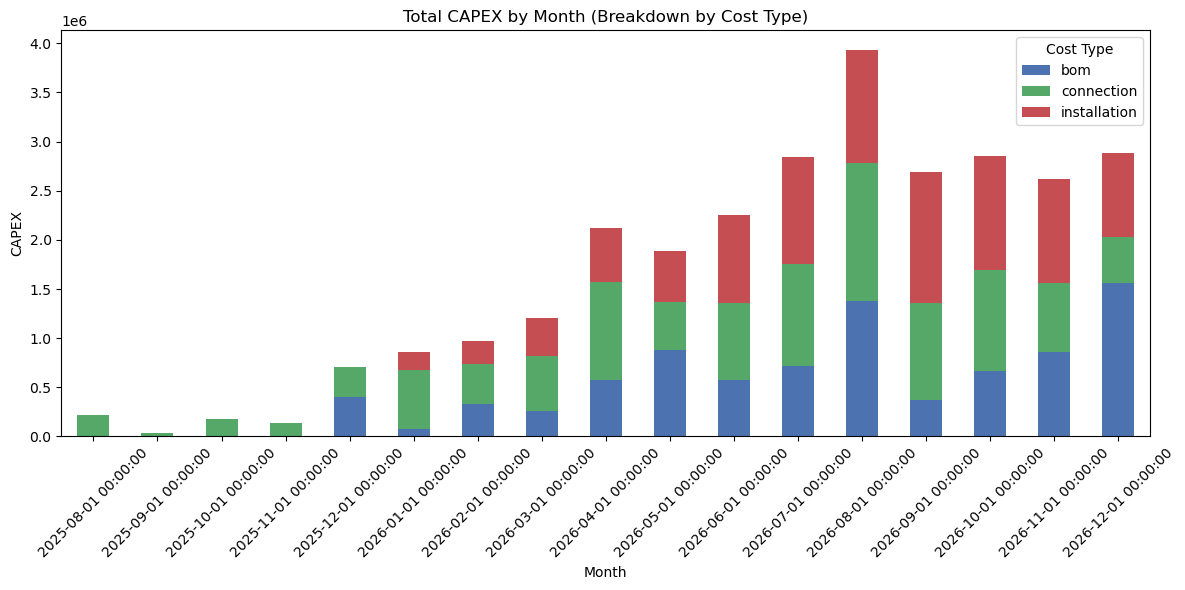

In [44]:
plot_total_capex_breakdown_by_type(schedule)

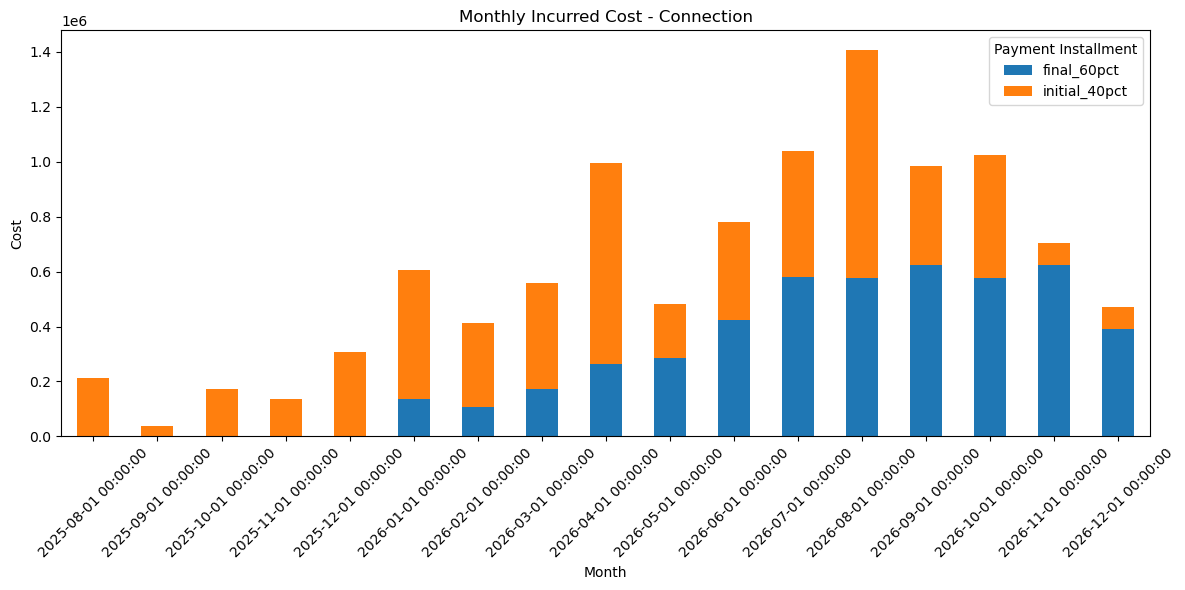

In [31]:
plot_incurred_cost_by_month_and_installment(schedule, "connection")


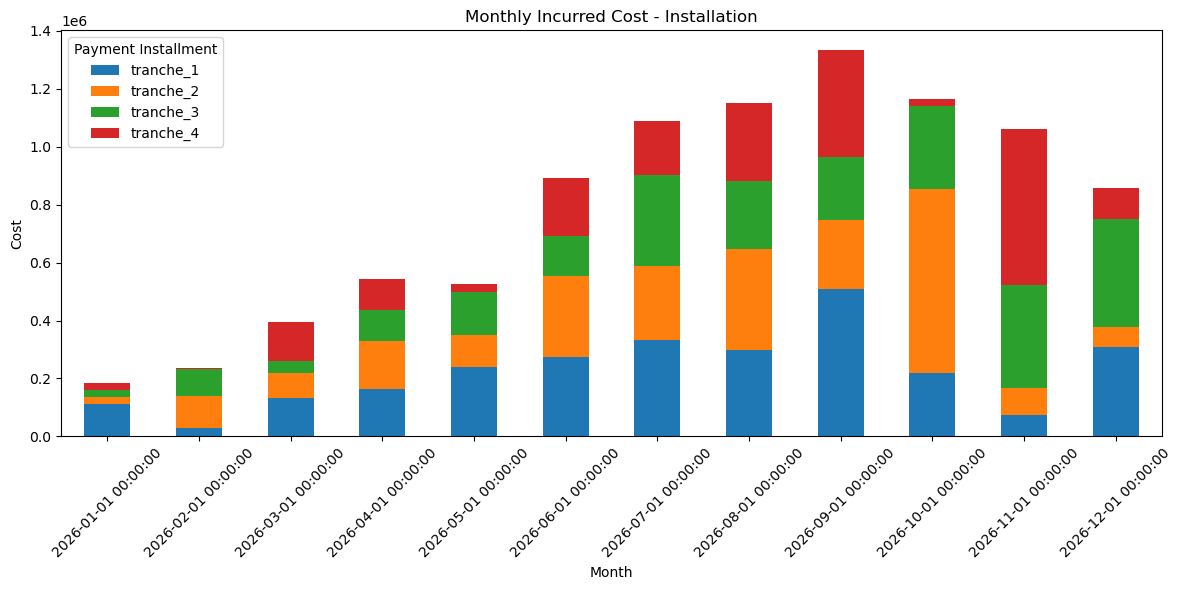

In [32]:
plot_incurred_cost_by_month_and_installment(schedule, "installation")


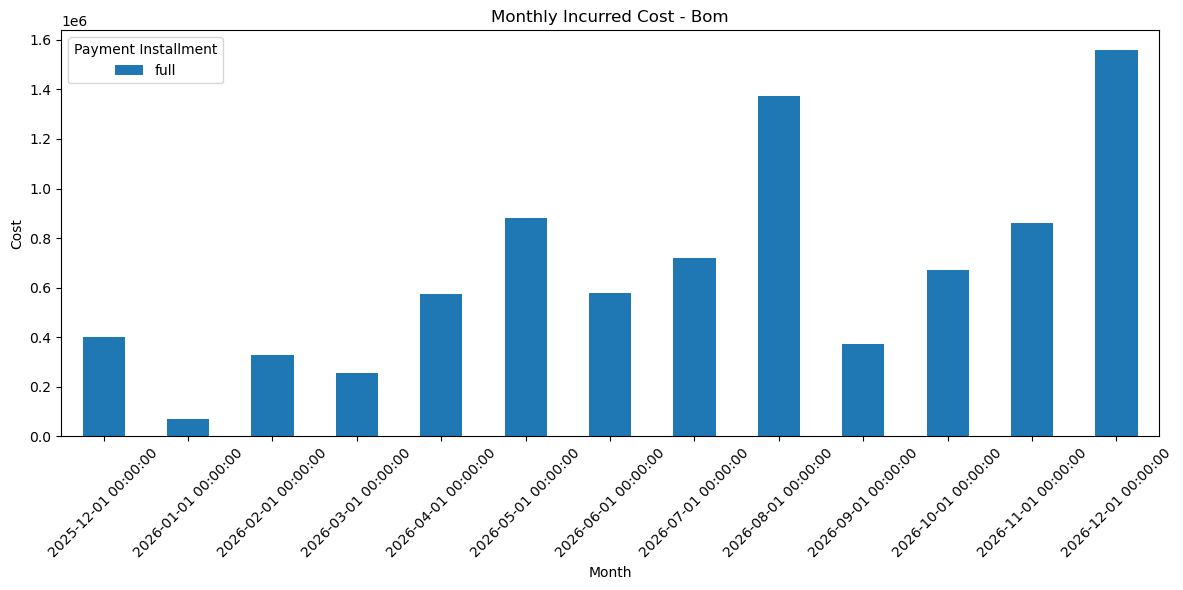

In [33]:
plot_incurred_cost_by_month_and_installment(schedule, "bom")